In [1]:
import os
import pandas as pd
import pyarrow
import fastparquet
import glob
import matplotlib

import matplotlib.ticker as mtick
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
files_path = glob.glob("./dataset/raw/*.snappy.parquet")
files_path

['./dataset/raw\\part-00000-tid-2779033056155408584-f6316110-4c9a-4061-ae48-69b77c7c8c36-4-1-c000.snappy.parquet',
 './dataset/raw\\part-00000-tid-5196563791502273604-c90d3a24-52f2-4955-b4ec-fb143aae74d8-4-1-c000.snappy.parquet',
 './dataset/raw\\part-00000-tid-6364321654468257203-dc13a5d6-36ae-48c6-a018-37d8cfe34cf6-263-1-c000.snappy.parquet']

In [3]:
df = pd.read_parquet(files_path[1], engine="fastparquet")
df

,internal_store_id,internal_product_id,distributor_id,transaction_date,reference_date,quantity,gross_value,net_value,gross_profit,discount,taxes
0,7384367747233276219,328903483604537190,9,2022-07-13,2022-07-01,1.0,38.125000,37.890625,10.042625,3.950000,0.234375
1,3536908514005606262,5418855670645487653,5,2022-03-21,2022-03-01,6.0,107.250000,106.440002,24.732002,17.100000,0.810000
2,3138231730993449825,1087005562675741887,6,2022-09-06,2022-09-01,3.0,56.625000,56.220001,14.124002,5.250000,0.405000
3,3681167389484217654,1401422983880045188,5,2022-09-11,2022-09-01,129.0,1037.160023,1037.160023,156.348026,479.880006,0.000000
4,7762413312337359369,6614994347738381720,4,2022-02-18,2022-02-01,1.0,26.230000,23.950241,6.550241,0.000000,2.279758
...,...,...,...,...,...,...,...,...,...,...,...
6560693,1439579822593789678,2523145330235258825,4,2022-12-06,2022-12-01,3.0,63.000000,61.379761,20.879761,0.000000,1.620240
6560694,2357589266242432199,3148628429396585683,4,2022-05-20,2022-05-01,1.0,12.300000,12.300000,3.650000,2.800000,0.000000
6560695,7245187752757348055,6668439675743950745,4,2022-08-17,2022-08-01,1.0,33.849998,31.570240,10.191240,0.000000,2.279758
6560696,8952609383990245450,3894706280449257667,5,2022-02-03,2022-02-01,4.0,74.556000,73.655998,17.991999,15.600000,0.900000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6560698 entries, 0 to 6560697
Data columns (total 11 columns):
 #   Column               Dtype         
---  ------               -----         
 0   internal_store_id    object        
 1   internal_product_id  object        
 2   distributor_id       object        
 3   transaction_date     datetime64[ns]
 4   reference_date       datetime64[ns]
 5   quantity             float64       
 6   gross_value          float64       
 7   net_value            float64       
 8   gross_profit         float64       
 9   discount             float64       
 10  taxes                float64       
dtypes: datetime64[ns](2), float64(6), object(3)
memory usage: 550.6+ MB


In [5]:
df.isnull().sum()

internal_store_id      0
internal_product_id    0
distributor_id         0
transaction_date       0
reference_date         0
quantity               0
gross_value            0
net_value              0
gross_profit           0
discount               0
taxes                  0
dtype: int64

In [6]:
df.notnull().sum() 

internal_store_id      6560698
internal_product_id    6560698
distributor_id         6560698
transaction_date       6560698
reference_date         6560698
quantity               6560698
gross_value            6560698
net_value              6560698
gross_profit           6560698
discount               6560698
taxes                  6560698
dtype: int64

In [7]:
num_duplicadas = df.duplicated().sum()
print("Número de linhas duplicadas:", num_duplicadas)

Número de linhas duplicadas: 0


In [8]:
df.columns

Index(['internal_store_id', 'internal_product_id', 'distributor_id',
       'transaction_date', 'reference_date', 'quantity', 'gross_value',
       'net_value', 'gross_profit', 'discount', 'taxes'],
      dtype='object')

In [9]:
df.nunique()

internal_store_id       15086
internal_product_id      7092
distributor_id              8
transaction_date          365
reference_date             12
quantity                16449
gross_value            173883
net_value              216337
gross_profit           363451
discount               121528
taxes                   12531
dtype: int64

In [44]:
num_cols = ['quantity', 'gross_value', 'net_value', 'gross_profit', 'discount', 'taxes']

pd.set_option('display.float_format', '{:,.0f}'.format)  # sem casas decimais, com vírgula

df[num_cols].describe()

,quantity,gross_value,net_value,gross_profit,discount,taxes
count,"6,560,698","6,560,698","6,560,698","6,560,698","6,560,698","6,560,698"
mean,8,123,119,22,28,4
std,80,866,865,233,385,11
min,"-1,530","-42,673","-39,848","-274,396","-13,097","-4,099"
25%,1,28,27,7,0,0
50%,2,42,41,11,2,1
75%,4,92,88,22,9,3
max,"94,230","604,174","604,174","274,416","240,083","2,073"


In [10]:
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['week'] = df['transaction_date'].dt.isocalendar().week
df['dayofweek'] = df['transaction_date'].dt.day_name()


In [11]:
df['quantity']

0            1.0
1            6.0
2            3.0
3          129.0
4            1.0
           ...  
6560693      3.0
6560694      1.0
6560695      1.0
6560696      4.0
6560697      2.0
Name: quantity, Length: 6560698, dtype: float64

In [ ]:
df = df.sort_values('transaction_date')
daily_total = df.groupby(df['transaction_date'].dt.date)['quantity'].sum()

In [62]:
daily_total

transaction_date
2022-01-01       759
2022-01-02     3,756
2022-01-03    37,400
2022-01-04    88,380
2022-01-05    72,289
               ...  
2022-12-27   158,205
2022-12-28   131,970
2022-12-29   117,835
2022-12-30    68,583
2022-12-31     1,297
Name: quantity, Length: 365, dtype: float64

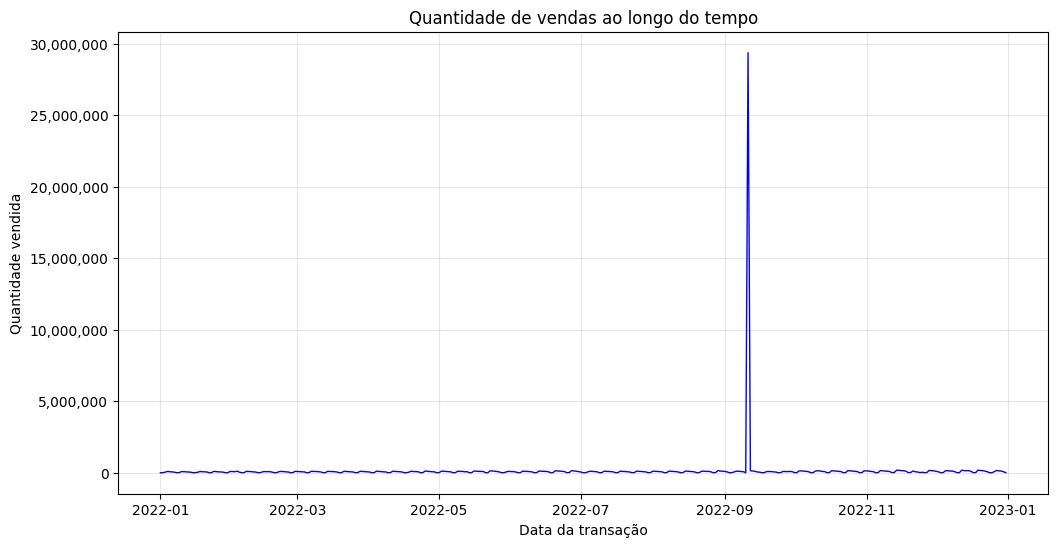

In [47]:
# gráfico simples de linha
plt.figure(figsize=(12,6))
plt.plot(daily_total, color='blue', lw=1)
plt.title("Quantidade de vendas ao longo do tempo")
plt.xlabel("Data da transação")
plt.ylabel("Quantidade vendida")
plt.grid(True, alpha=0.3)
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
plt.show()


In [48]:
daily_total# 'daily_total' é sua Series com soma diária
max_day = daily_total.idxmax()
max_day_value = daily_total.max()

print(f"Dia com pico: {max_day}, total vendido: {max_day_value}")


Dia com pico: 2022-09-11, total vendido: 29381814.275557622


In [50]:
# Pegando todas as linhas do DataFrame que correspondem a esse dia
peak_rows = df[df['transaction_date'].dt.date == max_day]

peak_rows


,internal_store_id,internal_product_id,distributor_id,transaction_date,reference_date,quantity,gross_value,net_value,gross_profit,discount,taxes,year,month,week,dayofweek
4167901,9112671094689434340,4400284663216610386,6,2022-09-11,2022-09-01,306,"1,590","1,590",324,359,0,2022,9,36,Sunday
2254282,5940138707587455236,2303727811338492139,6,2022-09-11,2022-09-01,84,461,461,85,126,0,2022,9,36,Sunday
2748616,1996096385248846560,3612097765749154369,10,2022-09-11,2022-09-01,2,36,36,9,3,0,2022,9,36,Sunday
5504552,1498450377823765598,4938000164057550340,9,2022-09-11,2022-09-01,48,391,391,105,67,0,2022,9,36,Sunday
2254279,4514412263790943852,8176384535280860253,5,2022-09-11,2022-09-01,280,"2,208","2,208",296,"1,085",0,2022,9,36,Sunday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1890188,4309474241319292940,7776281080438582461,5,2022-09-11,2022-09-01,24,16,16,-6,25,0,2022,9,36,Sunday
646944,3956939953510989238,5016785074551984721,9,2022-09-11,2022-09-01,54,457,457,115,141,0,2022,9,36,Sunday
1613954,7157409589028495184,4532811244969767948,5,2022-09-11,2022-09-01,29,933,933,330,"1,481",0,2022,9,36,Sunday
4555674,7829254819532449913,1371936917923350372,9,2022-09-11,2022-09-01,6,168,167,43,12,1,2022,9,36,Sunday


In [52]:
peak_rows.groupby('internal_store_id')['quantity'].sum().sort_values(ascending=False)

internal_store_id
6491855528940268514   175,431
3025867614395044464   169,810
8723723113467008071   131,795
4304226119364518876   130,292
9171644843739559005   126,487
                        ...  
5460085409070805928        -2
8070438308173384647        -6
6265859395586771998        -9
1562688395195974018       -12
725288784466296791        -12
Name: quantity, Length: 7192, dtype: float64

In [53]:
peak_rows.groupby('internal_product_id')['quantity'].sum().sort_values(ascending=False)

internal_product_id
3212701144500706568   872,593
2995245061726159069   824,574
5854098638082429437   767,814
1380288516179470221   692,375
3620674245436818138   635,409
                        ...  
6764925179613146127        -0
6127456226485495086        -0
7085828737366588081        -0
3626236708592140872        -1
4921307992373377973        -1
Name: quantity, Length: 1629, dtype: float64

In [54]:
# Total vendido por produto nesse dia
peak_rows.groupby('internal_product_id')['quantity'].sum().sort_values(ascending=False).head(20)

internal_product_id
3212701144500706568   872,593
2995245061726159069   824,574
5854098638082429437   767,814
1380288516179470221   692,375
3620674245436818138   635,409
4500561597898984528   556,823
828956132720074702    451,412
2389585171061933527   436,047
2394950933694010774   426,120
1690125846152117227   417,657
8752906129044353959   402,962
3654799619916051085   390,741
1776377728354810244   387,447
8961542818471010617   373,933
4794695800414206309   296,314
1365813714550729758   288,489
1471722963249789482   275,138
2427215902003685075   269,509
6504514533420270914   243,777
2703190777496458820   241,968
Name: quantity, dtype: float64

In [55]:

# Total vendido por loja nesse dia
peak_rows.groupby('internal_store_id')['quantity'].sum().sort_values(ascending=False).head(20)


internal_store_id
6491855528940268514   175,431
3025867614395044464   169,810
8723723113467008071   131,795
4304226119364518876   130,292
9171644843739559005   126,487
1365839146278641704   125,426
7059328007645110932   123,253
4374038751643985193   120,888
5130630496972372280   118,944
7195906766187577140   109,891
8294871217390043140    97,102
4882947442884300565    95,184
906070645731736912     93,175
7366853685985846137    90,709
6337402841339348330    89,335
2720921832183866690    86,265
4003964282058636604    85,225
6434414063399492998    81,965
5226403828926175217    81,593
8173585566175703293    80,635
Name: quantity, dtype: float64

In [57]:
# Agrupar por loja e por dia
median_per_day_store = df.groupby(
    [df['internal_product_id'], df['transaction_date'].dt.date]
)['quantity'].median().reset_index()

# Renomear colunas para ficar mais legível
median_per_day_store.columns = ['internal_product_id', 'date', 'median_quantity']

print(median_per_day_store.head())


   internal_product_id        date  median_quantity
0  1000423277513436210  2022-05-09                1
1  1000423277513436210  2022-05-11                1
2  1000423277513436210  2022-05-12                1
3  1000423277513436210  2022-05-16                1
4  1000423277513436210  2022-05-31                1


In [ ]:
# Agrupar por loja e por dia
median_per_day_store = df.groupby(
    [df['internal_store_id'], df['transaction_date'].dt.date]
)['quantity'].median().reset_index()

# Renomear colunas para ficar mais legível
median_per_day_store.columns = ['internal_store_id', 'date', 'median_quantity']

print(median_per_day_store.head())


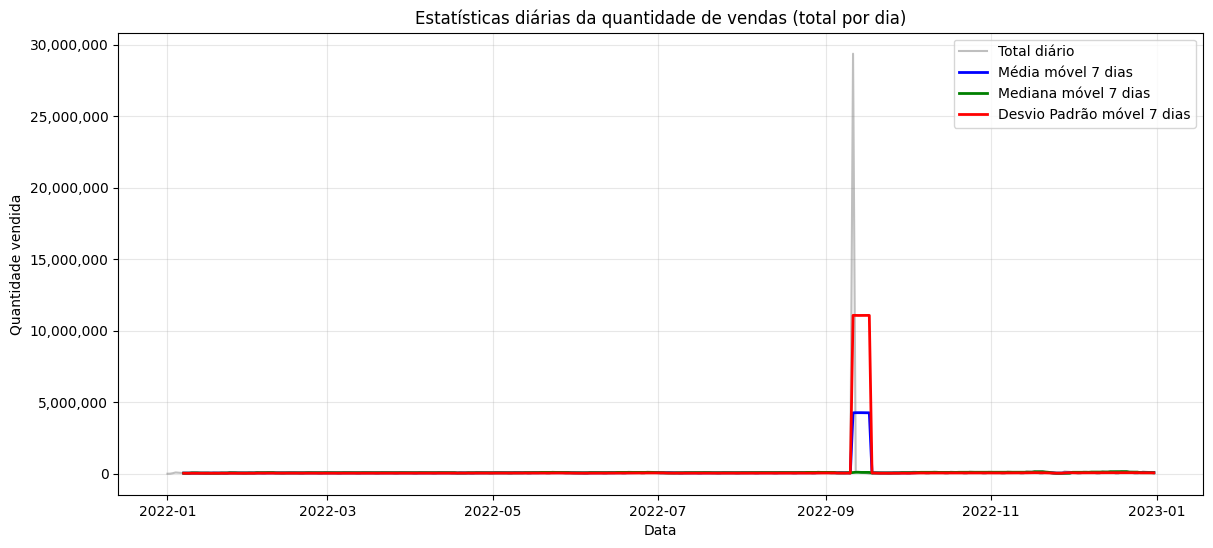

In [16]:
daily_total = df.groupby(df['transaction_date'].dt.date)['quantity'].sum()
daily_total.index = pd.to_datetime(daily_total.index)

# cálculo de estatísticas móveis (opcional: média, mediana e std de 7 dias)
daily_stats_total = pd.DataFrame({
    'total': daily_total,
    'mean': daily_total.rolling(window=7).mean(),    # média móvel 7 dias
    'median': daily_total.rolling(window=7).median(),# mediana móvel 7 dias
    'std': daily_total.rolling(window=7).std()       # desvio padrão móvel 7 dias
})

# plot
plt.figure(figsize=(14,6))
plt.plot(daily_stats_total.index, daily_stats_total['total'], label='Total diário', color='gray', alpha=0.5)
plt.plot(daily_stats_total.index, daily_stats_total['mean'], label='Média móvel 7 dias', color='blue', lw=2)
plt.plot(daily_stats_total.index, daily_stats_total['median'], label='Mediana móvel 7 dias', color='green', lw=2)
plt.plot(daily_stats_total.index, daily_stats_total['std'], label='Desvio Padrão móvel 7 dias', color='red', lw=2)

plt.title("Estatísticas diárias da quantidade de vendas (total por dia)")
plt.xlabel("Data")
plt.ylabel("Quantidade vendida")
plt.legend()
plt.grid(True, alpha=0.3)

# forçar números inteiros no eixo Y
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

plt.show()

In [17]:
mean_of_mean = daily_stats_total['mean'].mean()

# Mediana de todas as medianas diárias
median_of_median = daily_stats_total['median'].median()

# Média do desvio padrão diário
mean_of_std = daily_stats_total['std'].mean()

print(f"Média total das médias diárias: {mean_of_mean:.2f}")
print(f"Mediana das medianas diárias: {median_of_median:.2f}")
print(f"Média do desvio padrão diário: {mean_of_std:.2f}")


Média total das médias diárias: 147606.00
Mediana das medianas diárias: 72463.66
Média do desvio padrão diário: 261283.00


In [18]:
df_filtered = df[df['quantity'] >= 0]


In [19]:
# limite superior pelo percentil 99
upper_limit = df_filtered['quantity'].quantile(0.99)

# identificar outliers superiores
outliers_upper = df_filtered[df_filtered['quantity'] > upper_limit]

print(f"Número de outliers superiores: {outliers_upper.shape[0]}")
print(f"Porcentagem de outliers superiores: {(outliers_upper.shape[0] / df_filtered.shape[0] * 100):.2f}%")


Número de outliers superiores: 64849
Porcentagem de outliers superiores: 1.00%


In [20]:
# removendo outliers superiores
df_clean = df_filtered[df_filtered['quantity'] <= upper_limit]

print(f"Linhas restantes após remoção de outliers: {df_clean.shape[0]}")


Linhas restantes após remoção de outliers: 6425735


In [38]:
df['quantity'].mean()

np.float64(8.125893322711086)

In [40]:
df['quantity'].min()

np.float64(-1530.0)

In [39]:
df['quantity'].max()

np.float64(94230.0)

In [ ]:
from scipy.stats import zscore
import pandas as pd

# total de vendas por dia
daily_total = df.groupby(d['transaction_date'].dt.date)['quantity'].sum()
daily_total.index = pd.to_datetime(daily_total.index)

# calcular Z-score
daily_total_z = zscore(daily_total)

threshold = 3

daily_total_clean = daily_total[(daily_total_z >= -threshold) & (daily_total_z <= threshold)]
df_clean = df[~df['transaction_date'].dt.date.isin(daily_total_clean)]
print(f"Número de dias removidos como outliers: {len(daily_total) - len(daily_total_clean)}")


Número de dias removidos como outliers: 1


In [32]:
df.shape

(6560698, 15)

In [33]:
df_clean.shape

(6560698, 15)

In [27]:
df_clean

,internal_store_id,internal_product_id,distributor_id,transaction_date,reference_date,quantity,gross_value,net_value,gross_profit,discount,taxes,year,month,week,dayofweek
5372077,2904283814836480430,700484830392455456,4,2022-01-01,2022-01-01,5.0,46.250000,46.250000,11.250000,15.250000,0.000000,2022,1,52,Saturday
4785512,1073673009638227380,1078622472225871166,4,2022-01-01,2022-01-01,4.0,37.000000,37.000000,9.000000,12.200000,0.000000,2022,1,52,Saturday
5322073,2904283814836480430,1267019189808386798,4,2022-01-01,2022-01-01,5.0,46.250000,46.250000,11.250000,15.250000,0.000000,2022,1,52,Saturday
3351950,1073673009638227380,3379576219453733902,4,2022-01-01,2022-01-01,2.0,52.240002,46.160648,9.210649,16.799999,6.079354,2022,1,52,Saturday
5684144,7258564421045379389,519576013096278235,4,2022-01-01,2022-01-01,7.0,114.379997,114.379997,27.999998,17.780001,0.000000,2022,1,52,Saturday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
396282,8300521596900285165,1428095470563688104,9,2022-12-31,2022-12-01,3.0,75.974998,75.434998,16.493998,2.850000,0.540000,2022,12,52,Saturday
3044438,4942800552888849164,8741831804550298457,7,2022-12-31,2022-12-01,10.0,80.400002,76.784592,8.504592,0.000000,3.615410,2022,12,52,Saturday
1637478,7395510820998539091,7152037836400898950,5,2022-12-31,2022-12-01,2.0,320.000000,317.519989,102.519989,0.000000,2.480000,2022,12,52,Saturday
265498,8173585566175703293,1271951761907094129,9,2022-12-31,2022-12-01,8.0,189.800003,188.360001,41.128002,31.600000,1.440000,2022,12,52,Saturday


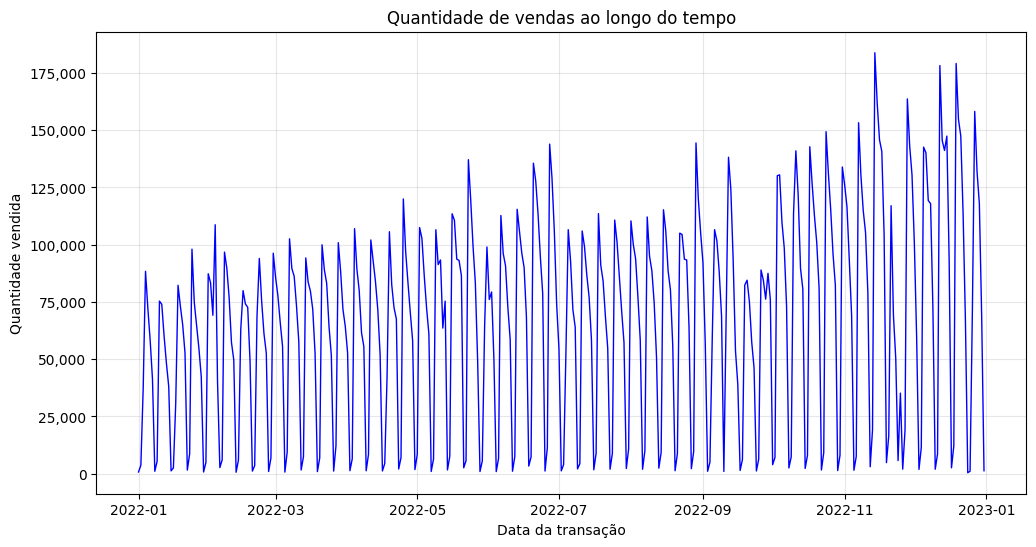

In [31]:
# gráfico simples de linha
plt.figure(figsize=(12,6))
plt.plot(daily_total_clean, color='blue', lw=1)
plt.title("Quantidade de vendas ao longo do tempo")
plt.xlabel("Data da transação")
plt.ylabel("Quantidade vendida")
plt.grid(True, alpha=0.3)
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
plt.show()


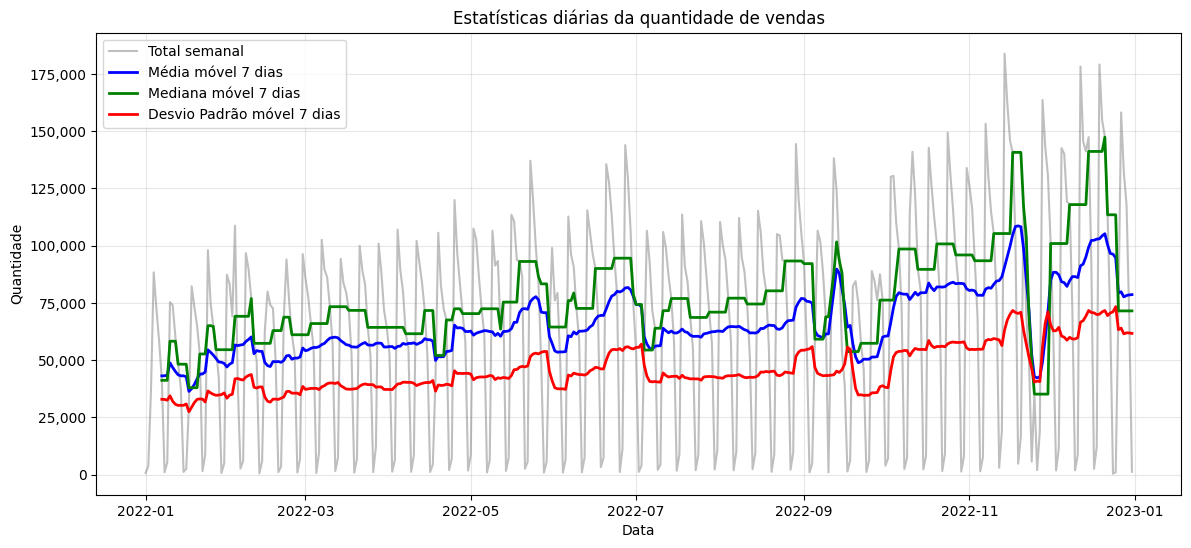

In [ ]:
daily_stats_total = pd.DataFrame({
    'total': daily_total_clean,
    'mean': daily_total_clean.rolling(window=7).mean(),    # média móvel de 7 dias
    'median': daily_total_clean.rolling(window=7).median(), # mediana móvel de 7 dias
    'std': daily_total_clean.rolling(window=7).std()        # desvio padrão móvel de 7 dias
})

plt.figure(figsize=(14,6))
plt.plot(daily_stats_total.index, daily_stats_total['total'], label='Total semanal', color='gray', alpha=0.5)
plt.plot(daily_stats_total.index, daily_stats_total['mean'], label='Média móvel 7 dias', color='blue', lw=2)
plt.plot(daily_stats_total.index, daily_stats_total['median'], label='Mediana móvel 7 dias', color='green', lw=2)
plt.plot(daily_stats_total.index, daily_stats_total['std'], label='Desvio Padrão móvel 7 dias', color='red', lw=2)

plt.title("Estatísticas diárias da quantidade de vendas")
plt.xlabel("Data")
plt.ylabel("Quantidade")
plt.legend()
plt.grid(True, alpha=0.3)

# Forçar números inteiros/absolutos no eixo Y
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

plt.show()


In [25]:
daily_total_clean


transaction_date
2022-01-01       759.000000
2022-01-02      3755.750000
2022-01-03     37400.166668
2022-01-04     88379.977776
2022-01-05     72289.024995
                  ...      
2022-12-27    158204.941662
2022-12-28    131969.644445
2022-12-29    117835.433335
2022-12-30     68583.256939
2022-12-31      1297.000000
Name: quantity, Length: 364, dtype: float64

In [ ]:
# Média total da média diária
mean_of_mean = daily_stats_total['mean'].mean()

# Mediana de todas as medianas diárias
median_of_median = daily_stats_total['median'].median()

# Média do desvio padrão diário
mean_of_std = daily_stats_total['std'].mean()

print(f"Média total das médias diárias: {mean_of_mean:.2f}")
print(f"Mediana das medianas diárias: {median_of_median:.2f}")
print(f"Média do desvio padrão diário: {mean_of_std:.2f}")


Média total das médias diárias: 65946.21
Mediana das medianas diárias: 72463.66
Média do desvio padrão diário: 46249.21


Interpretação dos números

Média total das médias diárias: 65,946

Indica que, em média, cada dia tem ~66 mil vendas totais somando todas as transações.

Esse valor dá uma boa noção geral do volume diário.

Mediana das medianas diárias: 72,463

A mediana é um pouco maior que a média, mostrando que a maioria dos dias tem vendas próximas a 72 mil, mas existem alguns dias com vendas mais baixas que puxam a média para baixo.

Média do desvio padrão diário: 46,249

Há uma variabilidade razoável entre os dias, mas não é exagerada.

Ou seja, não existem picos extremos muito frequentes, e a série diária é relativamente consistente.

In [23]:
df_clean.to_parquet('./dataset/processed/transacoes.parquet', engine='pyarrow', index=False)

In [ ]:
df

In [63]:
median_per_day_store = df.groupby(
    [df['internal_store_id'], df['transaction_date'].dt.date]
)['quantity'].median().reset_index()

median_per_day_store.columns = ['internal_store_id', 'date', 'median_quantity']


In [64]:
daily_total = df.groupby(df['transaction_date'].dt.date)['quantity'].sum()


In [65]:
max_day = daily_total.idxmax()
print(f"Dia com pico: {max_day}, total vendido: {daily_total[max_day]}")


Dia com pico: 2022-09-11, total vendido: 29381814.275557622


In [155]:
peak_rows = df[df['transaction_date'].dt.date == max_day]
peak_rows

,internal_store_id,internal_product_id,distributor_id,transaction_date,reference_date,quantity,gross_value,net_value,gross_profit,discount,taxes,year,month,week,dayofweek,date_only,median_quantity
4245444,9112671094689434340,4400284663216610386,6,2022-09-11,2022-09-01,306,"1,590","1,590",324,359,0,2022,9,36,Sunday,2022-09-11,24
4245445,5940138707587455236,2303727811338492139,6,2022-09-11,2022-09-01,84,461,461,85,126,0,2022,9,36,Sunday,2022-09-11,24
4245446,1996096385248846560,3612097765749154369,10,2022-09-11,2022-09-01,2,36,36,9,3,0,2022,9,36,Sunday,2022-09-11,24
4245447,1498450377823765598,4938000164057550340,9,2022-09-11,2022-09-01,48,391,391,105,67,0,2022,9,36,Sunday,2022-09-11,24
4245448,4514412263790943852,8176384535280860253,5,2022-09-11,2022-09-01,280,"2,208","2,208",296,"1,085",0,2022,9,36,Sunday,2022-09-11,24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4551996,4309474241319292940,7776281080438582461,5,2022-09-11,2022-09-01,24,16,16,-6,25,0,2022,9,36,Sunday,2022-09-11,24
4551997,3956939953510989238,5016785074551984721,9,2022-09-11,2022-09-01,54,457,457,115,141,0,2022,9,36,Sunday,2022-09-11,24
4551998,7157409589028495184,4532811244969767948,5,2022-09-11,2022-09-01,29,933,933,330,"1,481",0,2022,9,36,Sunday,2022-09-11,24
4551999,7829254819532449913,1371936917923350372,9,2022-09-11,2022-09-01,6,168,167,43,12,1,2022,9,36,Sunday,2022-09-11,24


In [157]:
peak_rows['internal_store_id'].unique()

array(['9112671094689434340', '5940138707587455236',
       '1996096385248846560', ..., '3045641346555172172',
       '8280585188330787919', '4406356819561360590'],
      shape=(7192,), dtype=object)

In [159]:
median_per_store = df[df['date_only'] != pd.to_datetime('2022-09-11')].groupby('internal_store_id')['quantity'].median().rename('median_quantity')
df = df.merge(median_per_store, on='internal_store_id', how='left')


In [160]:
# Limite máximo: mediana histórica * algum fator (ex: 10)
df.loc[(df['date_only'] == pd.to_datetime('2022-09-11')) & 
       (df['quantity'] > df['median_quantity']*10), 'quantity'] = df['median_quantity']


KeyError: 'median_quantity'

In [96]:
# Criar coluna apenas com a data (sem hora)
df['date_only'] = df['transaction_date'].dt.date

# Contar dias únicos por produto
days_per_product = df.groupby('internal_product_id')['date_only'].nunique().reset_index()
days_per_product.columns = ['internal_product_id', 'days_sold']


In [98]:
products_to_keep = days_per_product[days_per_product['days_sold'] > 1]['internal_product_id']

df_filtered = df[df['internal_product_id'].isin(products_to_keep)].copy()
df_filtered

,internal_store_id,internal_product_id,distributor_id,transaction_date,reference_date,quantity,gross_value,net_value,gross_profit,discount,taxes,year,month,week,dayofweek,date_only
5372077,2904283814836480430,700484830392455456,4,2022-01-01,2022-01-01,5,46,46,11,15,0,2022,1,52,Saturday,2022-01-01
4975675,9163231115567982267,8134049476259155367,5,2022-01-01,2022-01-01,1,30,30,7,2,0,2022,1,52,Saturday,2022-01-01
6217875,5426642061522415165,5168467358507505407,4,2022-01-01,2022-01-01,12,53,38,7,7,15,2022,1,52,Saturday,2022-01-01
3129627,1073673009638227380,3148628429396585683,4,2022-01-01,2022-01-01,2,24,24,7,8,0,2022,1,52,Saturday,2022-01-01
5342732,1493244414183181280,3048409779558813892,4,2022-01-01,2022-01-01,4,37,37,9,12,0,2022,1,52,Saturday,2022-01-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999894,7261047694428751812,1267019189808386798,8,2022-12-31,2022-12-01,6,60,60,15,10,0,2022,12,52,Saturday,2022-12-31
2470026,2009331647204935966,5202453704661408849,6,2022-12-31,2022-12-01,5,115,115,42,0,0,2022,12,52,Saturday,2022-12-31
5441351,5186345854775637737,4051297824522998476,7,2022-12-31,2022-12-01,6,24,24,4,0,0,2022,12,52,Saturday,2022-12-31
5377324,7261047694428751812,8966809205166240442,8,2022-12-31,2022-12-01,1,45,45,15,0,0,2022,12,52,Saturday,2022-12-31


In [99]:
counts = df.groupby(['internal_store_id', 'internal_product_id']).size().reset_index(name='count')
counts

,internal_store_id,internal_product_id,count
0,1000237487041964405,1837429607327399565,8
1,1000237487041964405,4038588102284338370,1
2,1000237487041964405,5429216175252037173,11
3,1000237487041964405,596381974901127871,6
4,1000237487041964405,7270233133454638680,9
...,...,...,...
1044305,997907800111849739,9199164571891113235,1
1044306,997907800111849739,9201926030466239921,17
1044307,997907800111849739,928243235850733102,1
1044308,997907800111849739,933845499679155839,9


In [100]:
duplicates = counts[counts['count'] > 1]
counts = df.value_counts(['internal_store_id', 'internal_product_id']).reset_index(name='count')
counts

,internal_store_id,internal_product_id,count
0,2275725734491727082,637448570435263100,216
1,2275725734491727082,4797439216678436447,187
2,2275725734491727082,802532509492578586,130
3,5236933832266054076,1938760505411922162,105
4,3188906461264284944,1938760505411922162,103
...,...,...,...
1044305,1000285336744471896,650162054185426354,1
1044306,1000285336744471896,1938760505411922162,1
1044307,1000285336744471896,1915930522577773480,1
1044308,997907800111849739,8752906129044353959,1


In [153]:
counts['count'].mean()

np.float64(6.282328044354646)

In [101]:
days_per_product = df.groupby('internal_product_id')['transaction_date'].nunique().reset_index()
days_per_product.columns = ['internal_product_id', 'days_sold']

In [102]:
days_per_product = df.groupby('internal_product_id')['date_only'].nunique().reset_index()
days_per_product.columns = ['internal_product_id', 'days_sold']

In [114]:
single_day_products = days_per_product[days_per_product['days_sold'] == 1]['internal_product_id']
single_day_products

7       1010742812441057506
11      1012020336292689550
41       105461563608081868
47      1060233940487700917
58      1069489352497454071
               ...         
7058     962441128011256234
7061      96683985058952347
7070     981834495003075119
7078     987806206033985525
7080     988563438435873285
Name: internal_product_id, Length: 924, dtype: object

In [115]:
df_single_day = df[df['internal_product_id'].isin(single_day_products)]
df_single_day

,internal_store_id,internal_product_id,distributor_id,transaction_date,reference_date,quantity,gross_value,net_value,gross_profit,discount,taxes,year,month,week,dayofweek,date_only
462416,3011006424598376420,4848920658057282127,4,2022-01-03,2022-01-01,1,82,79,23,0,3,2022,1,1,Monday,2022-01-03
1773883,5448728413677696163,4987992643104443879,4,2022-01-04,2022-01-01,1,43,43,15,0,0,2022,1,1,Tuesday,2022-01-04
5267882,6635525586630062668,5918976543889935557,4,2022-01-04,2022-01-01,1,37,35,9,0,2,2022,1,1,Tuesday,2022-01-04
5901007,222726668932213862,189953876876470985,4,2022-01-04,2022-01-01,1,79,75,21,0,4,2022,1,1,Tuesday,2022-01-04
657,567215957086962473,4715247228246581608,4,2022-01-05,2022-01-01,6,138,136,46,14,3,2022,1,1,Wednesday,2022-01-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
498011,7533127490227986089,6730443082170585683,4,2022-12-29,2022-12-01,1,187,176,52,0,11,2022,12,52,Thursday,2022-12-29
5280641,5571982191009984569,6240502002617543736,4,2022-12-29,2022-12-01,1,204,193,71,0,11,2022,12,52,Thursday,2022-12-29
4416901,905372509525062553,6240502002617543736,4,2022-12-29,2022-12-01,1,204,193,71,0,11,2022,12,52,Thursday,2022-12-29
6069093,3121401143759373521,6240502002617543736,4,2022-12-29,2022-12-01,2,408,386,143,0,22,2022,12,52,Thursday,2022-12-29


In [116]:
df_cleaned = df.drop(index=df_single_day.index)
df_cleaned

,internal_store_id,internal_product_id,distributor_id,transaction_date,reference_date,quantity,gross_value,net_value,gross_profit,discount,taxes,year,month,week,dayofweek,date_only
5372077,2904283814836480430,700484830392455456,4,2022-01-01,2022-01-01,5,46,46,11,15,0,2022,1,52,Saturday,2022-01-01
4975675,9163231115567982267,8134049476259155367,5,2022-01-01,2022-01-01,1,30,30,7,2,0,2022,1,52,Saturday,2022-01-01
6217875,5426642061522415165,5168467358507505407,4,2022-01-01,2022-01-01,12,53,38,7,7,15,2022,1,52,Saturday,2022-01-01
3129627,1073673009638227380,3148628429396585683,4,2022-01-01,2022-01-01,2,24,24,7,8,0,2022,1,52,Saturday,2022-01-01
5342732,1493244414183181280,3048409779558813892,4,2022-01-01,2022-01-01,4,37,37,9,12,0,2022,1,52,Saturday,2022-01-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999894,7261047694428751812,1267019189808386798,8,2022-12-31,2022-12-01,6,60,60,15,10,0,2022,12,52,Saturday,2022-12-31
2470026,2009331647204935966,5202453704661408849,6,2022-12-31,2022-12-01,5,115,115,42,0,0,2022,12,52,Saturday,2022-12-31
5441351,5186345854775637737,4051297824522998476,7,2022-12-31,2022-12-01,6,24,24,4,0,0,2022,12,52,Saturday,2022-12-31
5377324,7261047694428751812,8966809205166240442,8,2022-12-31,2022-12-01,1,45,45,15,0,0,2022,12,52,Saturday,2022-12-31


In [129]:
median_per_dayx = df_cleaned.groupby(['internal_store_id', 'transaction_date'])['quantity'].median().rename('median_quantity')

In [137]:
df_cleaned = df_cleaned.merge(median_per_dayx, on=['internal_store_id', 'transaction_date'], how='left')

In [ ]:
from scipy.stats import zscore

# Calcular zscore relativo à mediana
df_cleaned['zscore'] = (df_cleaned['quantity'] - df_cleaned['median_quantity']) / df_cleaned['median_quantity'].replace(0, 1)

# Substituir valores com zscore maior que 3 ou menor que -3
df_cleaned.loc[df_cleaned['zscore'].abs() > 3, 'quantity'] = df_cleaned['median_quantity']


In [139]:
df_cleaned

,internal_store_id,internal_product_id,distributor_id,transaction_date,reference_date,quantity,gross_value,net_value,gross_profit,discount,taxes,year,month,week,dayofweek,date_only,median_quantity,zscore
0,2904283814836480430,700484830392455456,4,2022-01-01,2022-01-01,5,46,46,11,15,0,2022,1,52,Saturday,2022-01-01,5,0
1,9163231115567982267,8134049476259155367,5,2022-01-01,2022-01-01,1,30,30,7,2,0,2022,1,52,Saturday,2022-01-01,2,-0
2,5426642061522415165,5168467358507505407,4,2022-01-01,2022-01-01,12,53,38,7,7,15,2022,1,52,Saturday,2022-01-01,12,0
3,1073673009638227380,3148628429396585683,4,2022-01-01,2022-01-01,2,24,24,7,8,0,2022,1,52,Saturday,2022-01-01,4,-0
4,1493244414183181280,3048409779558813892,4,2022-01-01,2022-01-01,4,37,37,9,12,0,2022,1,52,Saturday,2022-01-01,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6543793,7261047694428751812,1267019189808386798,8,2022-12-31,2022-12-01,6,60,60,15,10,0,2022,12,52,Saturday,2022-12-31,4,0
6543794,2009331647204935966,5202453704661408849,6,2022-12-31,2022-12-01,5,115,115,42,0,0,2022,12,52,Saturday,2022-12-31,2,2
6543795,5186345854775637737,4051297824522998476,7,2022-12-31,2022-12-01,6,24,24,4,0,0,2022,12,52,Saturday,2022-12-31,12,-0
6543796,7261047694428751812,8966809205166240442,8,2022-12-31,2022-12-01,1,45,45,15,0,0,2022,12,52,Saturday,2022-12-31,4,-1


In [144]:
df_cleaned['quantity'].describe()

count   6,543,798
mean            4
std            14
min        -1,530
25%             1
50%             1
75%             3
max         4,559
Name: quantity, dtype: float64

In [151]:
daily_sales = df_cleaned.groupby('date_only')['quantity'].sum().reset_index()
daily_sales.columns = ['date', 'total_quantity']


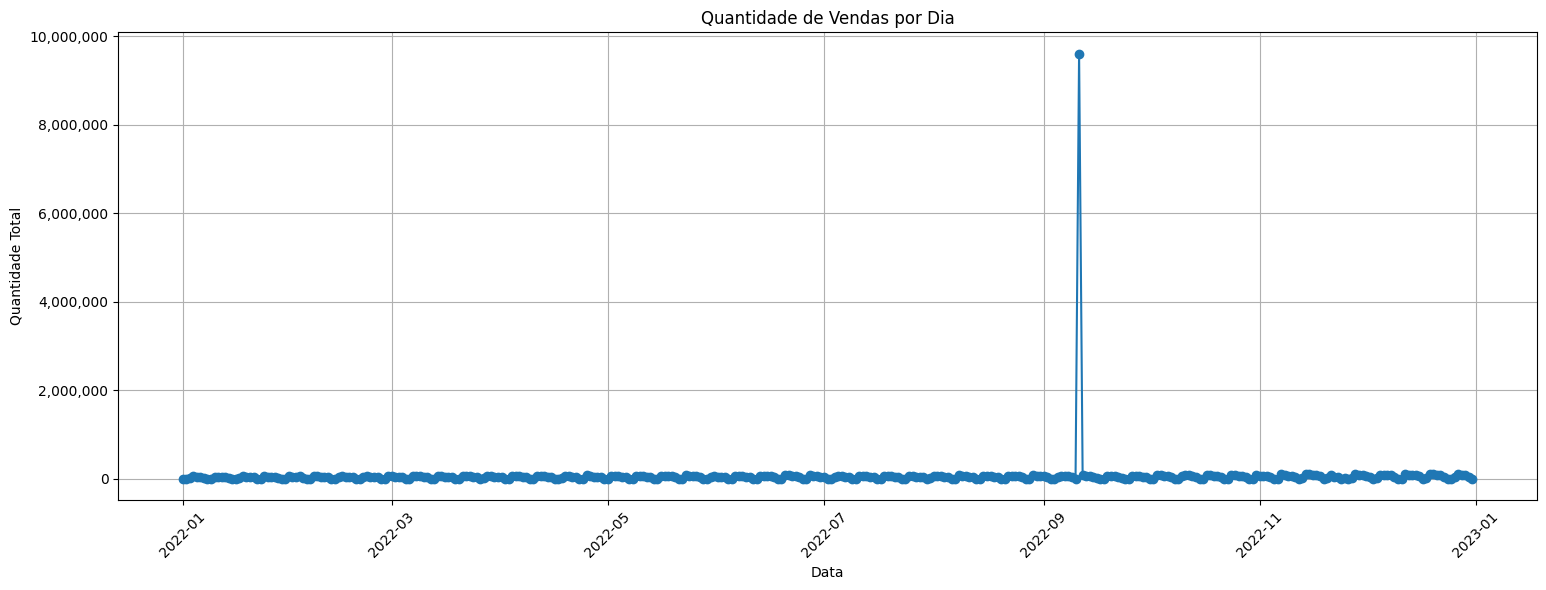

In [152]:
plt.figure(figsize=(15,6))
plt.plot(daily_sales['date'], daily_sales['total_quantity'], marker='o', linestyle='-')
plt.title('Quantidade de Vendas por Dia')
plt.xlabel('Data')
plt.ylabel('Quantidade Total')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
plt.show()


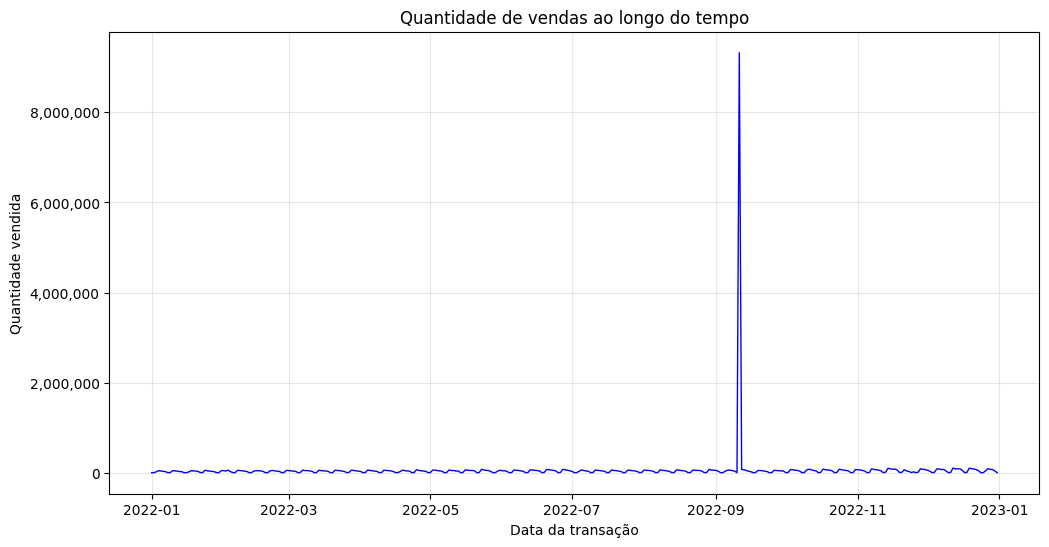

In [ ]:
df_cleaned = df_cleaned.sort_values('transaction_date')
daily_total = df_cleaned.groupby(df_cleaned['transaction_date'].dt.date)['median_quantity'].sum()
# gráfico simples de linha
plt.figure(figsize=(12,6))
plt.plot(daily_total, color='blue', lw=1)
plt.title("Quantidade de vendas ao longo do tempo")
plt.xlabel("Data da transação")
plt.ylabel("Quantidade vendida")
plt.grid(True, alpha=0.3)
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
plt.show()
